# Финальный проект Python: анализ продаж и температуры

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import csv
import re

plt.rcParams['figure.figsize'] = (12, 6)

## 1. Загрузка и подготовка данных продаж

In [2]:
sales_path = Path('data.csv')
if not sales_path.exists():
    raise FileNotFoundError('Файл data.csv не найден в текущей папке.')

df = pd.read_csv(sales_path)

print('Размер исходного датасета:', df.shape)
print('Исходные колонки:')
print(list(df.columns))
df.head()

Размер исходного датасета: (301355, 5)
Исходные колонки:
['Дата', 'Склад', 'Контрагент', 'Номенклатура', 'Количество']


,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


## 2. Автоматическое определение нужных колонок

In [3]:
# Приведем названия колонок к строковому виду
df.columns = [str(c).strip() for c in df.columns]

def find_col(columns, variants):
    lower_map = {c.lower(): c for c in columns}
    for variant in variants:
        if variant.lower() in lower_map:
            return lower_map[variant.lower()]
    for c in columns:
        c_low = c.lower()
        if any(v.lower() in c_low for v in variants):
            return c
    return None

date_col = find_col(df.columns, ['Дата', 'Date'])
number_col = find_col(df.columns, ['Количество', 'Number', 'Qty', 'quantity'])
store_col = find_col(df.columns, ['Склад', 'Store'])
product_col = find_col(df.columns, ['Номенклатура', 'Product', 'Товар'])

print('Определенные колонки:')
print('date_col   =', date_col)
print('number_col =', number_col)
print('store_col  =', store_col)
print('product_col=', product_col)

if date_col is None or number_col is None:
    raise ValueError('Не удалось определить столбцы даты и количества в data.csv.')

Определенные колонки:
date_col   = Дата
number_col = Количество
store_col  = Склад
product_col= Номенклатура


## 3. Приведение данных продаж к стандартному виду

In [4]:
sales = df.copy()

rename_map = {
    date_col: 'Date',
    number_col: 'Number'
}

if store_col is not None:
    rename_map[store_col] = 'Store'
if product_col is not None:
    rename_map[product_col] = 'Product'

sales = sales.rename(columns=rename_map)

sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')
sales['Number'] = pd.to_numeric(sales['Number'], errors='coerce')

sales = sales.dropna(subset=['Date', 'Number']).copy()

print('Размер очищенного датасета продаж:', sales.shape)
sales.head()

Размер очищенного датасета продаж: (301355, 5)


,Date,Store,Контрагент,Product,Number
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


## 4. Группировка продаж по дате

In [5]:
grouped_df = (
    sales.groupby('Date', as_index=False)['Number']
         .sum()
         .sort_values('Date')
         .reset_index(drop=True)
)

print('Размер grouped_df:', grouped_df.shape)
grouped_df.head()

Размер grouped_df: (205, 2)


,Date,Number
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


## 5. График количества продаж по дням

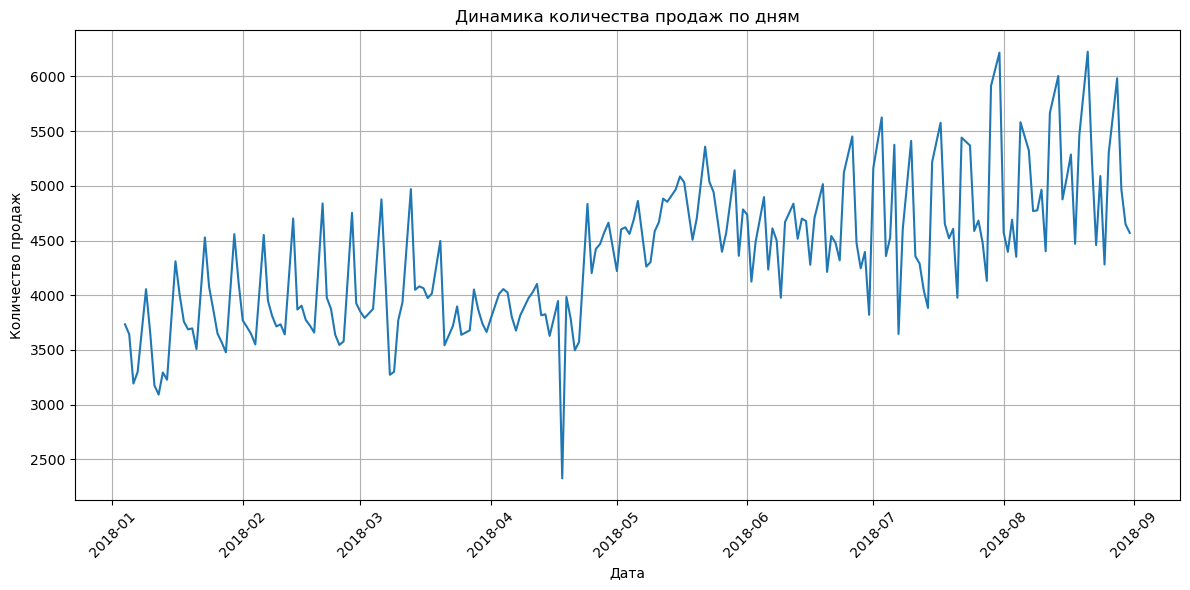

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(grouped_df['Date'], grouped_df['Number'])
plt.title('Динамика количества продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Строка с максимальным выбросом продаж

In [7]:
max_row = grouped_df.loc[grouped_df['Number'].idxmax()]
print('Строка с максимальным количеством продаж:')
max_row

Строка с максимальным количеством продаж:


Date      2018-08-21 00:00:00
Number                   6226
Name: 195, dtype: object

## 7. Топовый товар по продажам по средам за июнь, июль и август со склада 3

In [15]:
if 'Store' not in sales.columns or 'Product' not in sales.columns:
    print('В sales нет колонок Store и/или Product, поэтому этот пункт пропущен.')
else:
    sales['month'] = sales['Date'].dt.month
    sales['weekday'] = sales['Date'].dt.weekday  # среда = 2

    store_values = sales['Store'].astype(str).str.strip().str.lower()
    mask_store = store_values.isin(['store_3', 'store 3', '3', 'склад_3', 'склад 3'])

    filtered = sales[
        sales['month'].isin([6, 7, 8]) &
        (sales['weekday'] == 2) &
        mask_store
    ].copy()

    if filtered.empty:
        print('По заданному условию строки не найдены.')
    else:
        top_product = (
            filtered.groupby('Product', as_index=False)['Number']
                    .sum()
                    .sort_values('Number', ascending=False)
        )
        top_product.head(10)

## 8. Загрузка и подготовка погодных данных

In [9]:
weather_path = Path('weather.csv')
if not weather_path.exists():
    raise FileNotFoundError('Файл weather.csv не найден в текущей папке.')

def read_text(filepath, encodings=('utf-8-sig', 'utf-8', 'cp1251', 'latin1')):
    last_error = None
    for enc in encodings:
        try:
            with open(filepath, 'r', encoding=enc, errors='strict') as f:
                return f.read(), enc
        except Exception as e:
            last_error = e
    for enc in encodings:
        try:
            with open(filepath, 'r', encoding=enc, errors='ignore') as f:
                return f.read(), enc
        except Exception as e:
            last_error = e
    raise ValueError(f'Не удалось прочитать weather.csv. Последняя ошибка: {last_error}')

text, used_encoding = read_text(weather_path)
lines = text.splitlines()

print('Использованная кодировка:', used_encoding)
print('Первые 8 строк weather.csv:')
for line in lines[:8]:
    print(line)

Использованная кодировка: utf-8-sig
Первые 8 строк weather.csv:
# Метеостанция Астана, Казахстан, WMO_ID=35188, выборка с 01.06.2013 по 31.08.2013, все дни
# Кодировка: UTF-8
# Информация предоставлена сайтом "Расписание Погоды", rp5.ru
# Пожалуйста, при использовании данных, любезно указывайте названный сайт.
# Обозначения метеопараметров см. по адресу http://rp5.ru/archive.php?wmo_id=35188&lang=ru
#
"Местное время в Астане";"T";"Po";"P";"Pa";"U";"DD";"Ff";"ff10";"ff3";"N";"WW";"W1";"W2";"Tn";"Tx";"Cl";"Nh";"H";"Cm";"Ch";"VV";"Td";"RRR";"tR";"E";"Tg";"E'";"sss"
"31.08.2013 23:00";"13.5";"736.6";"767.6";"0.0";"71";"Ветер, дующий с юга";"2";"";"";"70 – 80%.";" ";"";"";"";"20.6";"Слоисто-кучевых, слоистых, кучевых или кучево-дождевых облаков нет.";"70 – 80%.";"2500 или более, или облаков нет.";"Высококучевые башенкообразные или хлопьевидные.";"Перистых, перисто-кучевых или перисто-слоистых нет.";"";"8.3";"";"";"";"";"";"";


## 9. Поиск строки заголовка weather.csv и чтение таблицы

In [10]:
def detect_header_and_sep(lines):
    seps = [';', '\t', ',']
    best = None

    for i, line in enumerate(lines[:120]):
        raw = line.strip()
        if not raw:
            continue

        lower = raw.lower()
        sep_counts = {sep: raw.count(sep) for sep in seps}
        best_sep = max(sep_counts, key=sep_counts.get)
        count = sep_counts[best_sep]

        score = 0
        if 'местное время' in lower or 'time' in lower or 'date' in lower:
            score += 3
        if re.search(r'(^|[;,\t ])t([;,\t ]|$)', lower):
            score += 3
        if count >= 3:
            score += 1

        if best is None or (score, count) > (best[0], best[1]):
            best = (score, count, i, best_sep)

    if best is None:
        raise ValueError('Не удалось определить строку заголовка weather.csv.')

    return best[2], best[3]

header_row, sep = detect_header_and_sep(lines)
print('header_row =', header_row)
print('sep =', repr(sep))

reader = csv.reader(lines[header_row:], delimiter=sep)
rows = list(reader)

header = [str(x).strip() for x in rows[0]]
data_rows = rows[1:]

normalized_rows = []
for row in data_rows:
    if not row:
        continue
    row = list(row)
    if len(row) < len(header):
        row += [''] * (len(header) - len(row))
    elif len(row) > len(header):
        row = row[:len(header)]
    normalized_rows.append(row)

weather_raw = pd.DataFrame(normalized_rows, columns=header)
weather_raw.columns = [str(c).strip() for c in weather_raw.columns]

print('Исходные колонки weather_raw:')
print(list(weather_raw.columns))
weather_raw.head()

header_row = 6
sep = ';'
Исходные колонки weather_raw:
['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch', 'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', "E'", 'sss']


,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2013 23:00,13.5,736.6,767.6,0.0,71,"Ветер, дующий с юга",2,,,...,Высококучевые башенкообразные или хлопьевидные.,"Перистых, перисто-кучевых или перисто-слоистых...",,8.3,,,,,,
1,31.08.2013 20:00,15.5,736.6,767.4,0.3,64,"Ветер, дующий с юга",2,,,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистые нитевидные, иногда когтевидные, не ра...",,8.7,,,,,,
2,31.08.2013 17:00,19.7,736.3,766.7,-0.3,46,"Ветер, дующий с западо-юго-запада",2,,,...,Клочья (часто чечевицеобразные) высококучевых ...,"Перистых, перисто-кучевых или перисто-слоистых...",20.0,7.8,,,,,,
3,31.08.2013 14:00,18.2,736.6,767.2,-0.9,49,"Ветер, дующий с запада",3,,,...,Высококучевые башенкообразные или хлопьевидные.,"Перистые нитевидные, иногда когтевидные, не ра...",20.0,7.3,,,,,,
4,31.08.2013 11:00,13.8,737.5,768.5,0.5,68,"Ветер, дующий с запада",2,,,...,"Высококучевые просвечивающие, полосами, либо о...",,20.0,8.0,,,,,,


## 10. Очистка weather.csv

In [11]:
def find_weather_col(columns, variants):
    lower_map = {c.lower(): c for c in columns}
    for variant in variants:
        if variant.lower() in lower_map:
            return lower_map[variant.lower()]
    for c in columns:
        c_low = c.lower()
        if any(v.lower() in c_low for v in variants):
            return c
    return None

weather_date_col = find_weather_col(weather_raw.columns, ['Местное время в Астане', 'Местное время', 'Date', 'Time'])
weather_temp_col = find_weather_col(weather_raw.columns, ['T', 'Temperature', 'Температура'])

if weather_date_col is None:
    weather_date_col = weather_raw.columns[0]

if weather_temp_col is None:
    raise ValueError('Не удалось определить столбец температуры в weather.csv.')

print('weather_date_col =', weather_date_col)
print('weather_temp_col =', weather_temp_col)

weather_df = weather_raw[[weather_date_col, weather_temp_col]].copy()
weather_df.columns = ['Date', 'Temperature']

weather_df['Date'] = pd.to_datetime(weather_df['Date'], errors='coerce', dayfirst=True)
weather_df['Temperature'] = (
    weather_df['Temperature']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.extract(r'([-+]?[0-9]*\.?[0-9]+)')[0]
)
weather_df['Temperature'] = pd.to_numeric(weather_df['Temperature'], errors='coerce')

weather_df = weather_df.dropna(subset=['Date', 'Temperature']).copy()

# Если в погоде несколько записей в день, берём среднюю температуру за день
weather_df = (
    weather_df.assign(Date=weather_df['Date'].dt.normalize())
              .groupby('Date', as_index=False)['Temperature']
              .mean()
              .sort_values('Date')
              .reset_index(drop=True)
)

print('Размер weather_df:', weather_df.shape)
weather_df.head()

weather_date_col = Местное время в Астане
weather_temp_col = T
Размер weather_df: (92, 2)


,Date,Temperature
0,2013-06-01,13.5875
1,2013-06-02,12.7875
2,2013-06-03,13.3250
3,2013-06-04,13.8500
4,2013-06-05,16.8750


## 11. Объединение продаж и температуры

In [12]:
# Прямой merge по полной дате
merged_df = pd.merge(
    grouped_df,
    weather_df,
    on='Date',
    how='inner'
)

print('Размер grouped_df:', grouped_df.shape)
print('Размер weather_df:', weather_df.shape)
print('Размер merged_df после прямого merge:', merged_df.shape)

# Если годы в sales и weather разные, делаем сопоставление по месяцу и дню
if merged_df.empty:
    print('Прямой merge пустой. Выполняем merge по месяцу и дню.')

    grouped_tmp = grouped_df.copy()
    weather_tmp = weather_df.copy()

    grouped_tmp['month'] = grouped_tmp['Date'].dt.month
    grouped_tmp['day'] = grouped_tmp['Date'].dt.day

    weather_tmp['month'] = weather_tmp['Date'].dt.month
    weather_tmp['day'] = weather_tmp['Date'].dt.day

    merged_df = pd.merge(
        grouped_tmp,
        weather_tmp[['month', 'day', 'Temperature']],
        on=['month', 'day'],
        how='inner'
    )

print('Итоговый размер merged_df:', merged_df.shape)
merged_df.head()

Размер grouped_df: (205, 2)
Размер weather_df: (92, 2)
Размер merged_df после прямого merge: (0, 3)
Прямой merge пустой. Выполняем merge по месяцу и дню.
Итоговый размер merged_df: (79, 5)


,Date,Number,month,day,Temperature
0,2018-06-01,4736,6,1,13.5875
1,2018-06-02,4124,6,2,12.7875
2,2018-06-03,4487,6,3,13.3250
3,2018-06-05,4897,6,5,16.8750
4,2018-06-06,4235,6,6,19.6750


## 12. График зависимости количества продаж от температуры

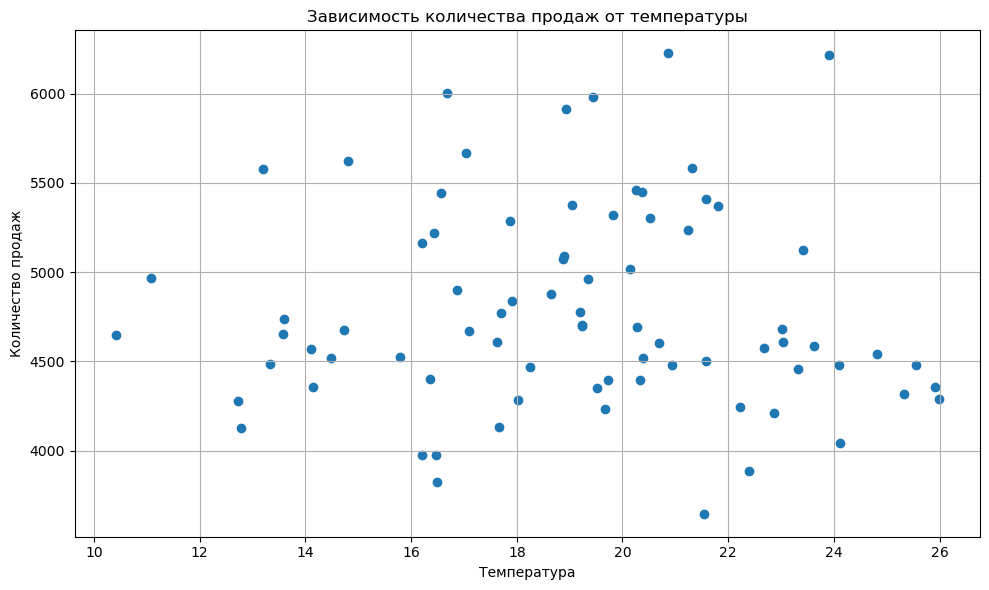

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Temperature'], merged_df['Number'])
plt.title('Зависимость количества продаж от температуры')
plt.xlabel('Температура')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. Отдельный график температуры

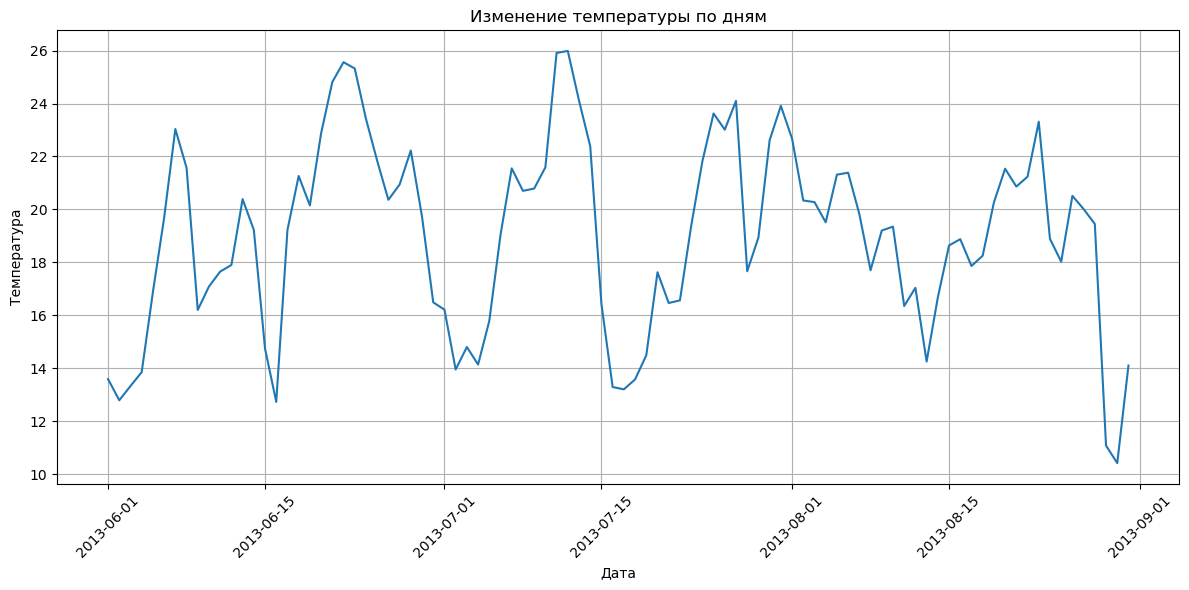

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(weather_df['Date'], weather_df['Temperature'])
plt.title('Изменение температуры по дням')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Итоговый вывод

В ходе анализа были изучены данные продаж и погодные условия.

Были выполнены:
- агрегация продаж по дням;
- поиск дня с максимальным количеством продаж;
- поиск топового товара по заданным условиям;
- очистка погодных данных;
- объединение двух датасетов;
- построение графиков продаж, температуры и зависимости продаж от температуры.